In [1]:
#Reading the data 
import pandas as pd 

file_path = "/kaggle/input/datasets/omaralwawi/dataset1/Employee Sample Data - A(1).xlsx"

df = pd.read_excel(file_path, engine='openpyxl')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   EEID           1000 non-null   object        
 1   Full Name      998 non-null    object        
 2   Job Title      999 non-null    object        
 3   Department     998 non-null    object        
 4   Business Unit  1000 non-null   object        
 5   Gender         999 non-null    object        
 6   Ethnicity      993 non-null    object        
 7   Age            994 non-null    float64       
 8   Hire Date      993 non-null    datetime64[ns]
 9   Annual Salary  989 non-null    float64       
 10  Bonus %        992 non-null    float64       
 11  Country        998 non-null    object        
 12  City           998 non-null    object        
 13  Exit Date      85 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(3), object(9)
memory usage: 109.5+ KB
None


In [2]:
# Cleaning the coulomns names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns)

Index(['eeid', 'full_name', 'job_title', 'department', 'business_unit',
       'gender', 'ethnicity', 'age', 'hire_date', 'annual_salary', 'bonus_%',
       'country', 'city', 'exit_date'],
      dtype='object')


In [3]:
#preproccessing 

#Saving the data into a copy for preproccessing
df_clean = df.copy()

# droping any duplicated columns
df_clean = df_clean.drop_duplicates()

#Droping any missing values in department / hire_date
df_clean = df_clean.dropna(subset=['department'])
df_clean = df_clean.dropna(subset=['hire_date'])
df_age_salary = df_clean.dropna(subset=['age', 'annual_salary'])

# Check department names
print("Unique departments:")
print(sorted(df_clean['department'].unique()))



Unique departments:
['Accounting', 'Engineering', 'Finance', 'Human Resources', 'IT', 'Marketing', 'Sales']


In [4]:
#tenure

#making sure that the dates are actually dates not (strings)
df_clean['hire_date'] = pd.to_datetime(df_clean['hire_date'], errors='coerce')
df_clean['exit_date'] = pd.to_datetime(df_clean['exit_date'], errors='coerce')

#Adding a new feature "employment_status" takes the values Active,Left  
df_clean['employment_status'] = df_clean['exit_date'].apply(
    lambda x: 'Left' if pd.notnull(x) else 'Active'
)

today = pd.Timestamp.today() #today date to help the calculations

#calculate how long each employee stayed
df_clean['tenure_days'] = df.apply(
    lambda row: (row['exit_date'] - row['hire_date']).days
    if pd.notnull(row['exit_date'])
    else (today - row['hire_date']).days,
    axis=1
)

#Converting the tenure days into years for easiear understanding
df_clean['tenure_years'] = (df_clean['tenure_days'] / 365).round(2)

print("Minimum tenure:", df_clean['tenure_years'].min())
print("Maximum tenure:", df_clean['tenure_years'].max())
print("Average tenure:", df_clean['tenure_years'].mean().round(2))

# Calculate the tenure ber department
tenure_by_department = df_clean.groupby('department')['tenure_years'].mean().reset_index().round(2)
tenure_by_department = tenure_by_department.sort_values(by='tenure_years', ascending=False)

tenure_by_department

Minimum tenure: 0.04
Maximum tenure: 34.33
Average tenure: 13.22


,department,tenure_years
4,IT,13.80
1,Engineering,13.50
6,Sales,13.47
2,Finance,13.40
3,Human Resources,13.13
5,Marketing,12.30
0,Accounting,12.02


In [5]:
#turnover

#counting the number of employees left per department
turnover = df_clean.groupby('department')['employment_status'] \
    .value_counts(normalize=True) \
    .unstack(fill_value=0)

turnover['turnover_rate'] = turnover['Left'].round(2)

turnover = turnover.reset_index()[['department', 'turnover_rate']]

#merging turnover with tenure

tenure = df_clean.groupby('department')['tenure_years'].mean().reset_index()

dept_analysis = pd.merge(tenure, turnover, on='department')

# Normalize tenure and turnover values
dept_analysis['tenure_norm'] = (
    (dept_analysis['tenure_years'] - dept_analysis['tenure_years'].min()) /
    (dept_analysis['tenure_years'].max() - dept_analysis['tenure_years'].min())
)

dept_analysis['turnover_norm'] = (
    (dept_analysis['turnover_rate'] - dept_analysis['turnover_rate'].min()) /
    (dept_analysis['turnover_rate'].max() - dept_analysis['turnover_rate'].min())
)

#Creating the stability  
dept_analysis['stability_score'] = (
    #dept_analysis['tenure_norm'] * (1 - dept_analysis['turnover_norm'])
    0.8 * dept_analysis['tenure_norm'] +
    0.2 * (1 - dept_analysis['turnover_norm'])
)


dept_analysis

,department,tenure_years,turnover_rate,tenure_norm,turnover_norm,stability_score
0,Accounting,12.017812,0.07,0.000000,0.166667,0.166667
1,Engineering,13.502611,0.11,0.834694,0.833333,0.701089
2,Finance,13.402941,0.08,0.778663,0.333333,0.756264
3,Human Resources,13.130650,0.09,0.625593,0.500000,0.600474
4,IT,13.796667,0.06,1.000000,0.000000,1.000000
5,Marketing,12.300833,0.12,0.159103,1.000000,0.127282
6,Sales,13.467266,0.07,0.814824,0.166667,0.818526


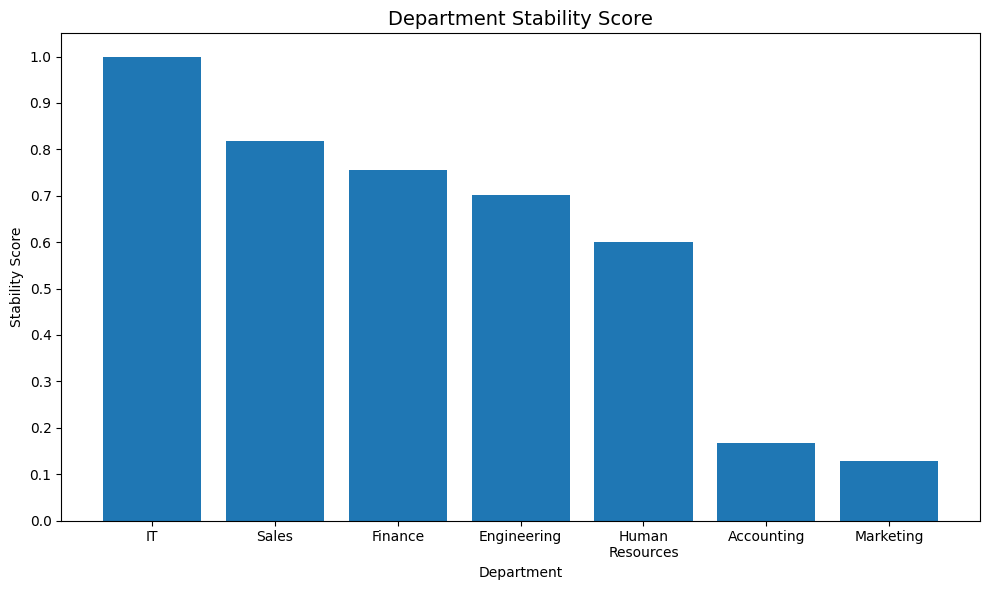

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Sort data
dept_analysis_sorted = dept_analysis.sort_values(by='stability_score', ascending=False)

# Replace spaces with new lines for better layout
dept_labels = dept_analysis_sorted['department'].str.replace(" ", "\n")

plt.figure(figsize=(10,6))

# Red bars (company theme)
bars = plt.bar(
    dept_labels,
    dept_analysis_sorted['stability_score'],
)

plt.title("Department Stability Score", fontsize=14)
plt.xlabel("Department")
plt.ylabel("Stability Score")

# Set y-axis ticks (0.0 → 1.0 step 0.1)
plt.yticks(np.arange(0, 1.1, 0.1))

plt.tight_layout()
plt.show()

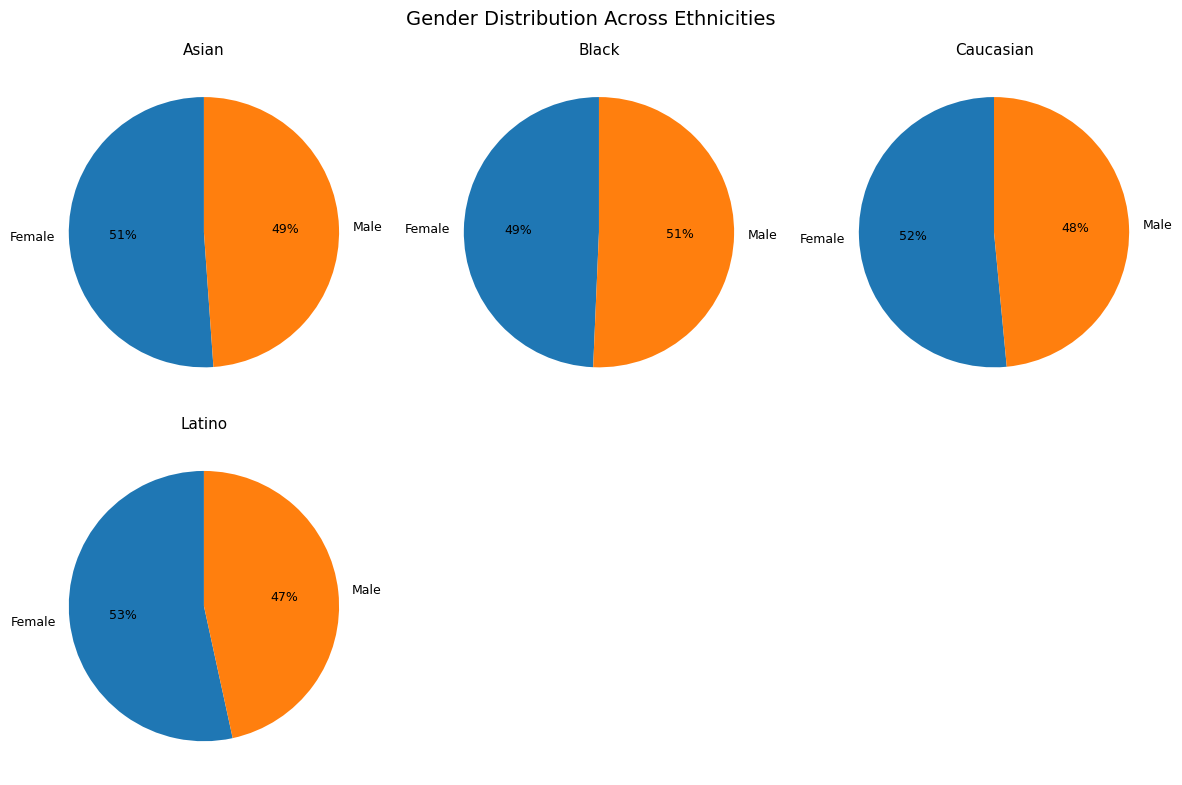

In [8]:
#gender percentage in each ethnicity

#count gender in eachethnicity
gender_ethnicity = df_clean.groupby(['ethnicity', 'gender']).size().unstack(fill_value=0)

#convert into percentage
gender_ethnicity_pct = gender_ethnicity.div(gender_ethnicity.sum(axis=1), axis=0) * 100

import math

# Prepare layout
ethnicities = gender_ethnicity_pct.index
n = len(ethnicities)

cols = 3  # number of columns
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 8))
axes = axes.flatten()

# Plot each pie
for i, ethnicity in enumerate(ethnicities):
    data = gender_ethnicity_pct.loc[ethnicity]
    
    axes[i].pie(
        data,
        labels=data.index,
        autopct='%1.0f%%',
        startangle=90,
        textprops={'fontsize': 9}
    )
    
    axes[i].set_title(ethnicity, fontsize=11)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Gender Distribution Across Ethnicities", fontsize=14)

plt.tight_layout()
plt.show()

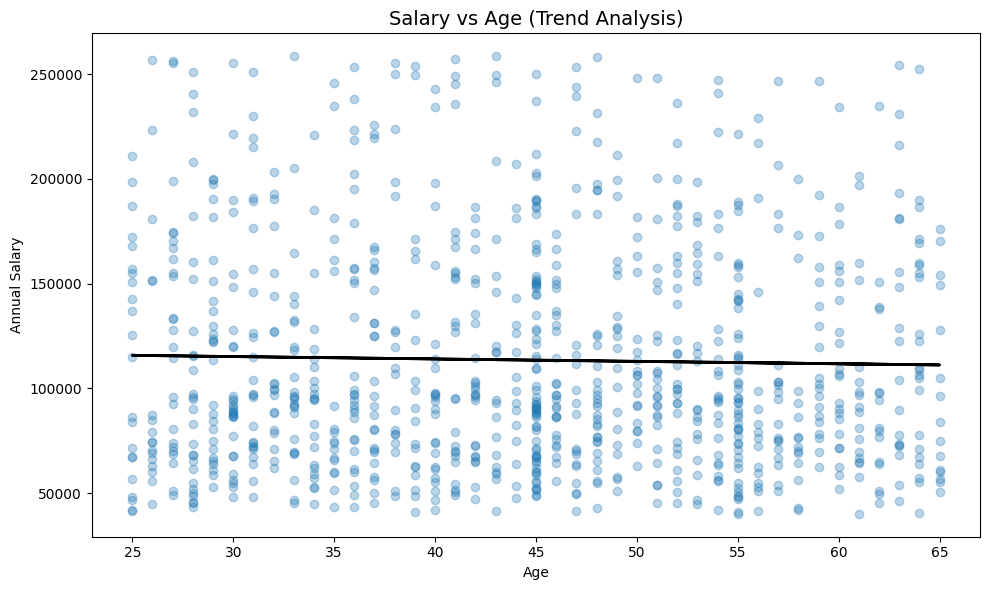

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

# Scatter plot (light for clarity)
plt.scatter(
    df_age_salary['age'],
    df_age_salary['annual_salary'],
    alpha=0.3,  # transparency to avoid clutter
)

# Create trend line
x = df_age_salary['age']
y = df_age_salary['annual_salary']

z = np.polyfit(x, y, 1)  # linear regression
p = np.poly1d(z)

plt.plot(
    x,
    p(x),
    color='black',
    linewidth=2
)

plt.title("Salary vs Age (Trend Analysis)", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Annual Salary")

plt.tight_layout()
plt.show()

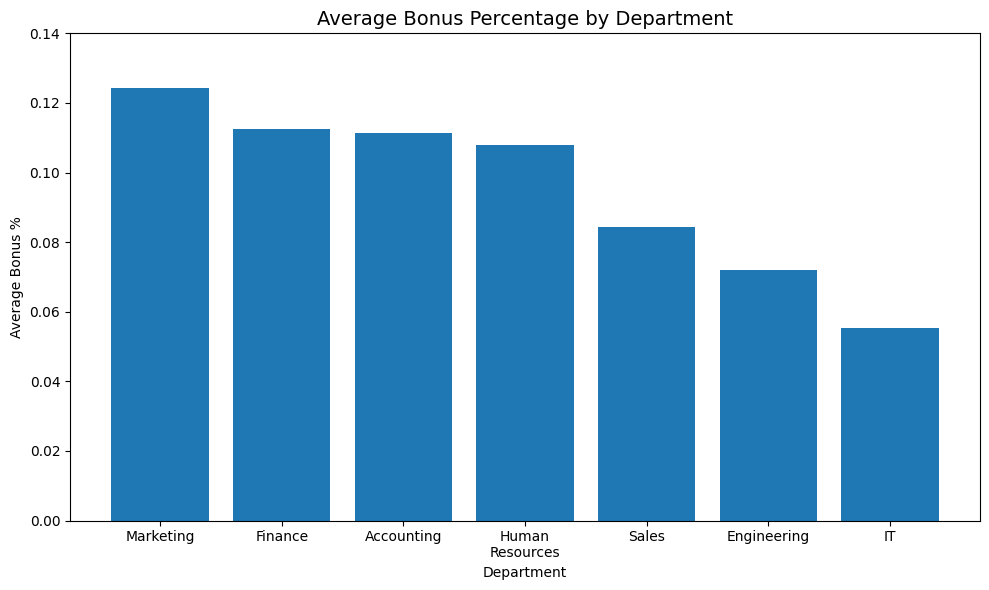

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate average bonus % per department
bonus_by_dept = df_clean.groupby('department')['bonus_%'].mean().reset_index()

# Sort descending
bonus_by_dept = bonus_by_dept.sort_values(by='bonus_%', ascending=False)

# Format department labels (multi-line if needed)
dept_labels = bonus_by_dept['department'].str.replace(" ", "\n")

plt.figure(figsize=(10,6))

bars = plt.bar(
    dept_labels,
    bonus_by_dept['bonus_%'],
)

plt.title("Average Bonus Percentage by Department", fontsize=14)
plt.xlabel("Department")
plt.ylabel("Average Bonus %")

# Clean y-axis ticks
max_val = bonus_by_dept['bonus_%'].max()
plt.yticks(np.arange(0, max_val + 0.02, 0.02))

plt.tight_layout()
plt.show()